# Day 1 — Variance Attribution in LLM Evaluation

## 🧪 Research Question

What drives instability in LLM-based evaluation judgments more strongly?

- prompt phrasing  
- temperature (stochasticity)  
- or their interaction  

Rather than focusing on score magnitude, this study investigates whether LLM evaluators preserve **consistent judgments and rankings** under repeated evaluations and small perturbations.

---

## 🧠 Hypothesis

We hypothesize that:

- prompt framing has a strong effect on evaluation consistency  
- stochasticity (temperature) introduces variability but does not fully determine judgment structure  
- most instability arises from interaction effects between prompt design and decoding noise  
- despite numeric fluctuations, ranking consistency is expected to be more stable than raw score values  

---

## 🎯 Goal

Measure the **stability of LLM-based evaluation systems** using ranking-based metrics:

- **Pairwise Consistency (PCS)** → agreement of judgments across repeated runs  
- **Kendall’s Tau** → stability of ranking order across evaluations  

This approach shifts the focus from variance in numeric scores to **consistency of decisions and relative ordering**.

---

## 🔬 Experimental Perspective

This study treats LLM-based evaluation systems as **stochastic measurement instruments for ranking tasks**, rather than deterministic scoring functions.

The goal is to quantify:

- how stable the model’s *judgments* are under repeated sampling  
- rather than how much its *numeric outputs* fluctuate  

We therefore analyze **judgment consistency under controlled perturbations**, to understand whether LLM evaluators behave more like:

- stable ranking systems with mild stochastic noise, or  
- highly variable judgment systems sensitive to prompt and sampling conditions

# 2. Imports + Setup

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.llm.ollama_client import OllamaClient
from src.utils.config import PROMPTS

from scipy.stats import kendalltau

import re

# 3. Model Setup

In [2]:
llm = OllamaClient(model="mistral:latest")

# 4. Define scoring function (IMPORTANT placeholder)

In [3]:
def build_scoring_prompt(question, answer):
    return f"""
You are an evaluator.

Score how well the answer relates to the question.

Rules:
- Score from 0 to 10
- 0 = completely unrelated
- 10 = perfectly relevant
- Output ONLY one integer between 0 and 10.
- If unsure, choose the closest score.
- Do NOT output anything else.
- Do NOT explain

Question: {question}
Answer: {answer}

Score:
"""

In [4]:
def extract_score(output):
    match = re.search(r"\b([0-9]|10)\b", output)
    if match:
        return int(match.group(1))
    return None

In [5]:
def evaluate_pair(question, answer, temperature=0.0):
    prompt = build_scoring_prompt(question, answer)
    output = llm.generate(prompt, temperature=temperature)
    score = extract_score(output)
    return score

# 5. Run Experiment

In [22]:
def run_experiment(question, answer, temperature=0.7, n_runs=10, n_samples=20):
    runs = []

    for _ in range(n_runs):
        scores = [
            evaluate_pair(question, answer, temperature)
            for _ in range(n_samples)
        ]
        runs.append(scores)

    return runs

# 6. Experimental design

In [23]:
temps = [0.0, 0.3, 0.7, 1.0]

prompts = {
    "p1": "What are you looking forward to in the next 12 months?",
    "p2": "Name one thing you expect in the next year.",
    "p3": "What excites you in the coming 12 months?"
}

answer = "Christmas"

# 7. Collect raw runs

In [25]:
data = {}

for t in temps:
    for p_name, question in prompts.items():
        runs = run_experiment(question, answer, temperature=t, n_runs=10, n_samples=20)

        data[(p_name, t)] = runs

[Ollama] 36.02s | temp=0.0
Output:  3
[Ollama] 0.48s | temp=0.0
Output:  3
[Ollama] 0.41s | temp=0.0
Output:  3
[Ollama] 0.42s | temp=0.0
Output:  3
[Ollama] 0.41s | temp=0.0
Output:  3
[Ollama] 0.40s | temp=0.0
Output:  3
[Ollama] 0.39s | temp=0.0
Output:  3
[Ollama] 0.38s | temp=0.0
Output:  3
[Ollama] 0.39s | temp=0.0
Output:  3
[Ollama] 0.38s | temp=0.0
Output:  3
[Ollama] 0.38s | temp=0.0
Output:  3
[Ollama] 0.40s | temp=0.0
Output:  3
[Ollama] 0.53s | temp=0.0
Output:  3
[Ollama] 0.41s | temp=0.0
Output:  3
[Ollama] 0.39s | temp=0.0
Output:  3
[Ollama] 0.38s | temp=0.0
Output:  3
[Ollama] 0.38s | temp=0.0
Output:  3
[Ollama] 0.38s | temp=0.0
Output:  3
[Ollama] 0.38s | temp=0.0
Output:  3
[Ollama] 0.40s | temp=0.0
Output:  3
[Ollama] 0.39s | temp=0.0
Output:  3
[Ollama] 0.38s | temp=0.0
Output:  3
[Ollama] 0.38s | temp=0.0
Output:  3
[Ollama] 0.38s | temp=0.0
Output:  3
[Ollama] 0.39s | temp=0.0
Output:  3
[Ollama] 0.39s | temp=0.0
Output:  3
[Ollama] 0.38s | temp=0.0
Output:  3


# 8. Pairwise Consistency Score (PCS)

## Definition:

How often two runs agree exactly.

In [28]:
def pcs(scores, tol=0.1):
    """
    scores = list of runs
    each run = list of integer scores
    """

    # 🔑 STEP 1: collapse each run into a single representative value
    run_means = [np.mean(run) for run in scores]

    agreements = 0
    total = 0

    # 🔑 STEP 2: compare runs at scalar level
    for i in range(len(run_means)):
        for j in range(i + 1, len(run_means)):
            agreements += int(abs(run_means[i] - run_means[j]) < tol)
            total += 1

    return agreements / total if total > 0 else 0

## Compute PCS table

In [29]:
pcs_results = []

for (prompt, temp), scores in data.items():
    pcs_results.append({
        "prompt": prompt,
        "temperature": temp,
        "PCS": pcs(scores)
    })

pcs_df = pd.DataFrame(pcs_results)
pcs_df

,prompt,temperature,PCS
0,p1,0.0,1.000000
1,p2,0.0,1.000000
2,p3,0.0,1.000000
3,p1,0.3,1.000000
4,p2,0.3,0.422222
5,p3,0.3,1.000000
6,p1,0.7,0.777778
7,p2,0.7,0.222222
8,p3,0.7,0.488889
9,p1,1.0,0.511111


# 9. Ranking Stability (Kendall Tau)

In [30]:
def ranking_stability(runs):
    """
    runs = list of score lists
    e.g. [
        [3,3,2,3],
        [3,2,3,3],
        [3,3,3,2]
    ]
    """

    taus = []

    for i in range(len(runs) - 1):
        a = runs[i]
        b = runs[i + 1]

        # safety check
        if len(a) != len(b):
            raise ValueError("Run lengths must match for Kendall Tau")

        tau, _ = kendalltau(a, b)

        if not np.isnan(tau):
            taus.append(tau)

    return np.mean(taus) if taus else 0

## Compute ranking stability

In [31]:
rank_results = []

for (prompt, temp), scores in data.items():
    rank_results.append({
        "prompt": prompt,
        "temperature": temp,
        "tau": ranking_stability(scores)
    })

rank_df = pd.DataFrame(rank_results)
rank_df

,prompt,temperature,tau
0,p1,0.0,0.000000
1,p2,0.0,0.000000
2,p3,0.0,0.000000
3,p1,0.3,0.000000
4,p2,0.3,0.061242
5,p3,0.3,0.000000
6,p1,0.7,-0.076472
7,p2,0.7,-0.059309
8,p3,0.7,-0.129186
9,p1,1.0,-0.037420


# 10. Final Summary Table

In [32]:
summary = pcs_df.merge(
    rank_df,
    on=["prompt", "temperature"]
)

summary

,prompt,temperature,PCS,tau
0,p1,0.0,1.000000,0.000000
1,p2,0.0,1.000000,0.000000
2,p3,0.0,1.000000,0.000000
3,p1,0.3,1.000000,0.000000
4,p2,0.3,0.422222,0.061242
5,p3,0.3,1.000000,0.000000
6,p1,0.7,0.777778,-0.076472
7,p2,0.7,0.222222,-0.059309
8,p3,0.7,0.488889,-0.129186
9,p1,1.0,0.511111,-0.037420


# 11. Visualization (IMPORTANT)

## PCS plot

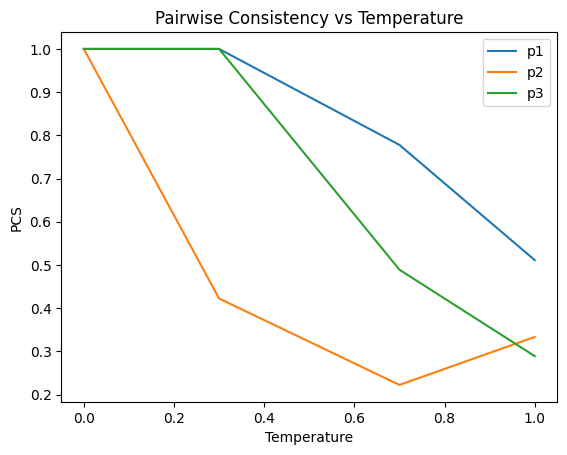

In [33]:
import matplotlib.pyplot as plt

for p in summary["prompt"].unique():
    subset = summary[summary["prompt"] == p]

    plt.plot(subset["temperature"], subset["PCS"], label=p)

plt.title("Pairwise Consistency vs Temperature")
plt.xlabel("Temperature")
plt.ylabel("PCS")
plt.legend()
plt.show()

## Ranking stability plot

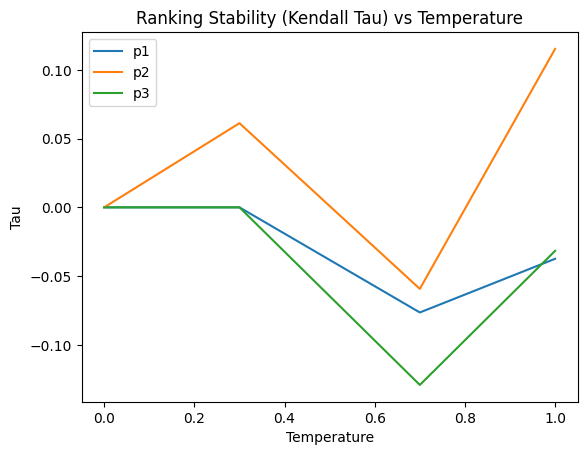

In [34]:
for p in summary["prompt"].unique():
    subset = summary[summary["prompt"] == p]

    plt.plot(subset["temperature"], subset["tau"], label=p)

plt.title("Ranking Stability (Kendall Tau) vs Temperature")
plt.xlabel("Temperature")
plt.ylabel("Tau")
plt.legend()
plt.show()

# 12. Final Interpretation Section

## Key Finding

LLM-based evaluation exhibits a structured degradation of stability as temperature increases.

At deterministic settings (T=0), the evaluator is perfectly consistent in its scoring behavior.

As temperature increases, instability emerges in a non-uniform way across prompts, suggesting that prompt phrasing interacts with stochastic decoding.

At higher temperatures, both Pairwise Consistency and Ranking Stability degrade, indicating a loss of reliable ordering structure rather than complete randomness.

## Insight

Stability is not uniformly affected by temperature; instead, it depends on prompt structure, indicating interaction effects between linguistic framing and decoding noise.